In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_dataset
from ultralytics import YOLO
from PIL import Image
from transformers import CLIPProcessor, CLIPVisionModelWithProjection
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "mps"
print(f"Using device: {device}")

Using device: mps


In [16]:
# STAGE 1: DATASET FILTERING & MAPPING
raw_dataset = load_dataset("jojogo9/freshness_of_fruits_and_veges_256")
original_labels = raw_dataset['train'].features['label'].names

# We only keep what YOLOv8 naturally knows
target_class_names = [
    'FreshApple', 'RottenApple', 
    'FreshBanana', 'RottenBanana', 
    'FreshOrange', 'RottenOrange'
]

target_original_ids = [original_labels.index(name) for name in target_class_names]
id_mapping = {old_id: new_id for new_id, old_id in enumerate(target_original_ids)}

def filter_classes(example):
    return example['label'] in target_original_ids

def remap_labels(example):
    example['label'] = id_mapping[example['label']]
    return example

remapped_dataset = raw_dataset.filter(filter_classes).map(remap_labels)
labels = target_class_names
num_classes = len(labels)

In [17]:
# STAGE 2: CLIP PREPROCESSING & DATALOADERS
# Load the official CLIP processor
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def clip_transform_fn(examples):
    # The processor automatically resizes to 224x224 and applies CLIP's specific normalization
    inputs = processor(images=[img.convert("RGB") for img in examples["image"]], return_tensors="pt")
    examples["pixel_values"] = inputs["pixel_values"]
    del examples["image"] # Prevent PyTorch collate errors
    return examples

transformed_ds = remapped_dataset.with_transform(clip_transform_fn)

train_loader = DataLoader(transformed_ds['train'], batch_size=32, shuffle=True)

if 'test' in transformed_ds:
    test_loader = DataLoader(transformed_ds['test'], batch_size=32, shuffle=False)
else:
    test_loader = DataLoader(transformed_ds['train'], batch_size=32, shuffle=False)

In [18]:
# STAGE 3: THE CLIP + MLP ARCHITECTURE

class CLIPFreshnessSpecialist(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Load the pre-trained CLIP vision encoder
        self.clip = CLIPVisionModelWithProjection.from_pretrained("openai/clip-vit-base-patch32")
        
        # FREEZE CLIP! We only want to use it as a feature extractor
        for param in self.clip.parameters():
            param.requires_grad = False
            
        # Add a tiny, trainable MLP head
        # CLIP's base model outputs a 512-dimensional embedding vector
        self.mlp = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3), # Helps prevent overfitting on small datasets
            nn.Linear(128, num_classes)
        )
        
    def forward(self, pixel_values):
        with torch.no_grad(): 
            clip_outputs = self.clip(pixel_values=pixel_values)
            # Extract the 512-D summary of the image
            image_embeds = clip_outputs.image_embeds 
            
        # Pass the summary to our classifier
        return self.mlp(image_embeds)

model = CLIPFreshnessSpecialist(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
# Higher learning rate (1e-3) because we are only training the small MLP
optimizer = optim.Adam(model.mlp.parameters(), lr=1e-3)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_att

In [19]:
# STAGE 5: SMART INFERENCE PIPELINE

yolo_model = YOLO('yolov8n.pt') 

def smart_clip_pipeline(image_path):
    results = yolo_model(image_path)
    img = Image.open(image_path).convert("RGB")
    
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)
    model.eval()
    
    # Map YOLO's COCO IDs to our allowed freshness classes
    valid_indices = {
        47: [0, 1], # Apple -> FreshApple/RottenApple
        46: [2, 3], # Banana -> FreshBanana/RottenBanana
        49: [4, 5],  # Orange -> FreshOrange/RottenOrange
        48: [0, 1]
    }
    
    with torch.no_grad():
        for r in results:
            for box in r.boxes:
                yolo_cls = int(box.cls)
                
                if yolo_cls in valid_indices:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    
                    # Add padding so CLIP sees the whole fruit
                    pad = 15
                    w, h = img.size
                    x1, y1 = max(0, x1-pad), max(0, y1-pad)
                    x2, y2 = min(w, x2+pad), min(h, y2+pad)
                    
                    crop = img.crop((x1, y1, x2, y2))
                    
                    # Process crop using CLIP's specific formatting
                    inputs = processor(images=crop, return_tensors="pt").to(device)
                    logits = model(inputs.pixel_values)
                    
                    # Filter logits to ONLY look at the valid freshness classes for this fruit
                    allowed_idx = valid_indices[yolo_cls]
                    filtered_logits = logits[0, allowed_idx] 
                    
                    probs = F.softmax(filtered_logits, dim=0)
                    best_local_idx = torch.argmax(filtered_logits).item()
                    final_class_idx = allowed_idx[best_local_idx]
                    
                    label_text = labels[final_class_idx]
                    conf = probs[best_local_idx].item()
                    
                    # Draw visual results
                    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=3, edgecolor='cyan', facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x1, y1-10, f"{label_text} ({conf*100:.1f}%)", 
                            color='black', fontsize=12, bbox=dict(facecolor='cyan', alpha=0.8))
                
    plt.axis('off')
    plt.show()

In [20]:
def train_clip_specialist(epochs=8):
    print(f"Starting CLIP-MLP training for {epochs} epochs...")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for batch in train_loader:
            inputs, targets = batch["pixel_values"].to(device), batch["label"].to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss / len(train_loader):.4f}")
    
    torch.save(model.state_dict(), "clip_freshness_smart.pth")
    print("Model weights saved successfully!")

In [21]:
# EVALUATION HELPER
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_clip_model(loader):
    print("\nEvaluating model on test data...")
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in loader:
            inputs, targets = batch["pixel_values"].to(device), batch["label"].to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
            
    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=labels))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.title("CLIP Freshness Confusion Matrix")
    plt.show()

In [22]:
# Train the MLP head (Should take seconds per epoch)
train_clip_specialist(epochs=8)

Starting CLIP-MLP training for 8 epochs...
Epoch 1/8 - Loss: 1.0430
Epoch 2/8 - Loss: 0.3327
Epoch 3/8 - Loss: 0.1812
Epoch 4/8 - Loss: 0.1342
Epoch 5/8 - Loss: 0.0950
Epoch 6/8 - Loss: 0.0804
Epoch 7/8 - Loss: 0.0651
Epoch 8/8 - Loss: 0.0518
Model weights saved successfully!



Evaluating model on test data...

--- Classification Report ---
              precision    recall  f1-score   support

  FreshApple       1.00      1.00      1.00       200
 RottenApple       1.00      0.99      1.00       200
 FreshBanana       1.00      1.00      1.00       200
RottenBanana       1.00      1.00      1.00       200
 FreshOrange       0.99      0.98      0.99       200
RottenOrange       0.98      0.99      0.99       200

    accuracy                           0.99      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      0.99      1.00      1200



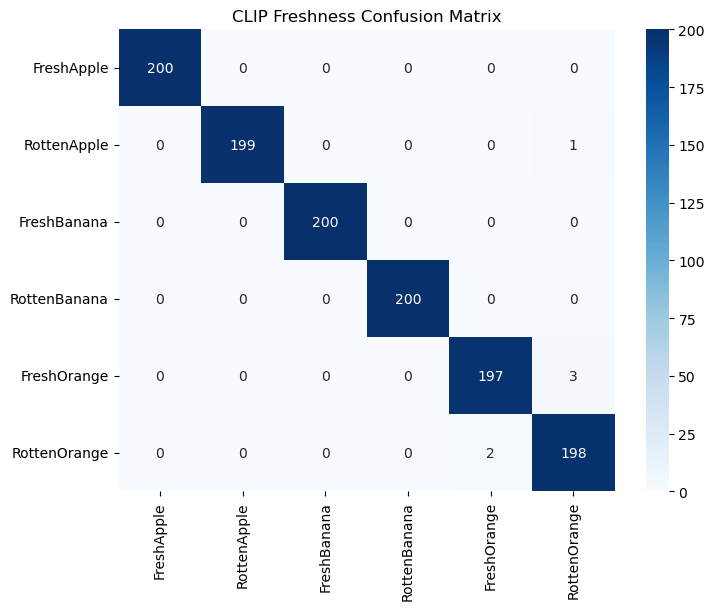

In [23]:
evaluate_clip_model(test_loader)


image 1/1 /Users/ngimagelusherpa/Documents/Image Processing and Computer Vision/final/rotton_apple.webp: 448x640 1 sandwich, 36.6ms
Speed: 1.7ms preprocess, 36.6ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)


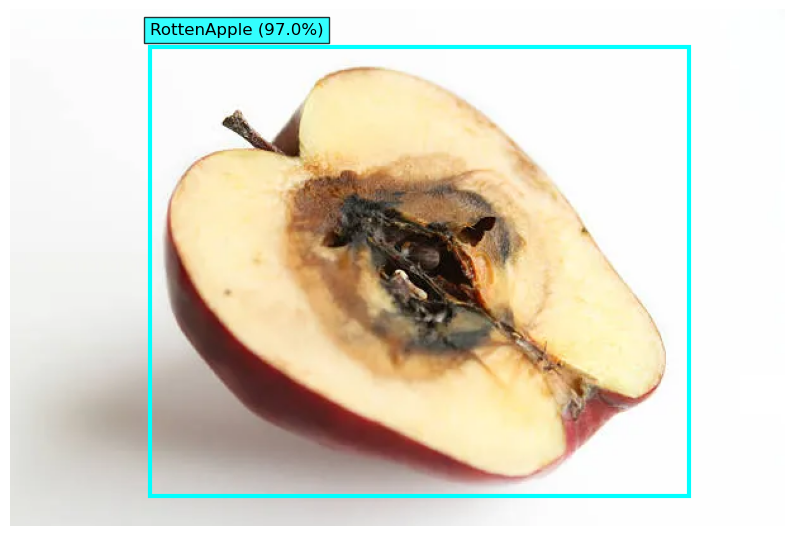

In [24]:
smart_clip_pipeline("rotton_apple.webp")